<a href="https://colab.research.google.com/github/IsabelaNeves1/am-t4-s1a2026/blob/main/prova20_isabela_neves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AVA 2 - CONSULTORIA DE INTELIGÊNCIA ARTIFICIAL
# ANAC - PREVISÃO DE ATRASOS DE VOOS
# Aluna: Isabela Neves da Silva

## Importações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils import resample


In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


# FASE 1 - EXTRAÇÃO

In [4]:
url = "https://siros.anac.gov.br/siros/registros/diversos/vra/2025/VRA_2025_04.csv"


df = pd.read_csv(
    url,
    sep=';',
    encoding='utf-8'
)


print("Dimensão da base:")
print(df.shape)


df.head()

Dimensão da base:
(80726, 20)


,Sigla ICAO Empresa Aérea,Empresa Aérea,Número Voo,Código DI,Código Tipo Linha,Modelo Equipamento,Número de Assentos,Sigla ICAO Aeroporto Origem,Descrição Aeroporto Origem,Partida Prevista,Partida Real,Sigla ICAO Aeroporto Destino,Descrição Aeroporto Destino,Chegada Prevista,Chegada Real,Situação Voo,Justificativa,Referência,Situação Partida,Situação Chegada
0,1ED,SERVICIOS AÉREOS PANAMERICANOS LTDA. SARPA S.A.S,3291,9,I,E145,50,SKBO,EL DORADO INTERNATIONAL AIRPORT - BOGOTÁ - COL...,15/04/2025 12:00,15/04/2025 12:22,SBEG,EDUARDO GOMES - MANAUS - AM - BRASIL,15/04/2025 15:00,15/04/2025 15:01,REALIZADO,NaN,2025-04-15,Pontual,Pontual
1,1ED,SERVICIOS AÉREOS PANAMERICANOS LTDA. SARPA S.A.S,3292,6,I,E145,50,SBEG,EDUARDO GOMES - MANAUS - AM - BRASIL,15/04/2025 16:00,15/04/2025 16:23,SYCJ,CHEDDI JAGAN INTERNATIONAL AIRPORT - GEORGETOW...,15/04/2025 17:55,15/04/2025 17:55,REALIZADO,NaN,2025-04-15,Pontual,Pontual
2,1ED,SERVICIOS AÉREOS PANAMERICANOS LTDA. SARPA S.A.S,3293,9,I,E145,50,SYCJ,CHEDDI JAGAN INTERNATIONAL AIRPORT - GEORGETOW...,15/04/2025 20:55,15/04/2025 18:00,SBEG,EDUARDO GOMES - MANAUS - AM - BRASIL,15/04/2025 22:50,15/04/2025 21:12,REALIZADO,NaN,2025-04-15,Antecipado,Antecipado
3,1ED,SERVICIOS AÉREOS PANAMERICANOS LTDA. SARPA S.A.S,3294,6,I,E145,50,SBEG,EDUARDO GOMES - MANAUS - AM - BRASIL,15/04/2025 23:50,15/04/2025 22:50,SKBO,EL DORADO INTERNATIONAL AIRPORT - BOGOTÁ - COL...,16/04/2025 02:45,16/04/2025 01:20,REALIZADO,NaN,2025-04-15,Antecipado,Antecipado
4,1ED,SERVICIOS AÉREOS PANAMERICANOS LTDA. SARPA S.A.S,3291,9,I,E145,50,SYCJ,CHEDDI JAGAN INTERNATIONAL AIRPORT - GEORGETOW...,30/04/2025 20:35,30/04/2025 22:09,SBEG,EDUARDO GOMES - MANAUS - AM - BRASIL,30/04/2025 22:15,30/04/2025 23:44,REALIZADO,NaN,2025-04-30,Atraso 60-120,Atraso 60-120


In [5]:
df.columns.tolist()

['Sigla ICAO Empresa Aérea',
 'Empresa Aérea',
 'Número Voo',
 'Código DI',
 'Código Tipo Linha',
 'Modelo Equipamento',
 'Número de Assentos',
 'Sigla ICAO Aeroporto Origem',
 'Descrição Aeroporto Origem',
 'Partida Prevista',
 'Partida Real',
 'Sigla ICAO Aeroporto Destino',
 'Descrição Aeroporto Destino',
 'Chegada Prevista',
 'Chegada Real',
 'Situação Voo',
 'Justificativa',
 'Referência',
 'Situação Partida',
 'Situação Chegada']

# FASE 2 - TRATAMENTO

## Conversão das datas brasileiras

In [6]:
df['Partida Prevista'] = pd.to_datetime(
    df['Partida Prevista'],
    dayfirst=True,
    errors='coerce'
)


df['Partida Real'] = pd.to_datetime(
    df['Partida Real'],
    dayfirst=True,
    errors='coerce'
)

## Remover registros sem datas necessárias


In [7]:
df.dropna(
    subset=[
        'Partida Prevista',
        'Partida Real'
    ],
    inplace=True
)

## FEATURE PRINCIPAL DA PROVA(desafio)

In [8]:
df['Minutos_Atraso'] = (
    df['Partida Real']
    -
    df['Partida Prevista']
).dt.total_seconds()/60


## Features de tempo


In [9]:
df['Hora'] = (
    df['Partida Prevista']
    .dt.hour
)


df['Dia_Semana'] = (
    df['Partida Prevista']
    .dt.dayofweek
)


df['Mes'] = (
    df['Partida Prevista']
    .dt.month
)

df['Dia_Mes'] = (
    df['Partida Prevista']
    .dt.day
)


df['Fim_Semana'] = (
    df['Partida Prevista']
    .dt.dayofweek >= 5
).astype(int)


df['Periodo'] = pd.cut(
    df['Hora'],
    bins=[-1, 6, 12, 18, 23],
    labels=[
        'Madrugada',
        'Manha',
        'Tarde',
        'Noite'
    ]
)

## CRIAÇÃO DO Y

In [10]:
df['Y_Atrasado'] = (
    df['Minutos_Atraso'] > 30
).astype(int)



print(
    df['Y_Atrasado']
    .value_counts()
)

Y_Atrasado
0    69804
1     6398
Name: count, dtype: int64


##Visualização do desbalanceamento

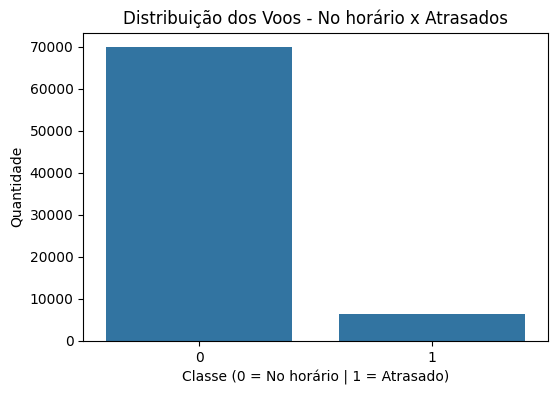

In [11]:
plt.figure(figsize=(6,4))


sns.countplot(
    data=df,
    x='Y_Atrasado'
)


plt.title(
    "Distribuição dos Voos - No horário x Atrasados"
)


plt.xlabel(
    "Classe (0 = No horário | 1 = Atrasado)"
)


plt.ylabel(
    "Quantidade"
)


plt.show()

#FASE 3 — ONE HOT ENCODING

(Correção da AVA 1)

In [12]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Empresa Aérea',
        'Sigla ICAO Aeroporto Origem',
        'Sigla ICAO Aeroporto Destino',
        'Modelo Equipamento',
        'Código Tipo Linha',
        'Periodo'
    ],
    drop_first=True,
    dtype=int
)

features_empresa = [
    coluna
    for coluna in df_encoded.columns
    if "Empresa Aérea_" in coluna
]

features_origem = [
    coluna
    for coluna in df_encoded.columns
    if "Sigla ICAO Aeroporto Origem_" in coluna
]

features_destino = [
    coluna
    for coluna in df_encoded.columns
    if "Sigla ICAO Aeroporto Destino_" in coluna
]

features_equipamento = [
    coluna
    for coluna in df_encoded.columns
    if "Modelo Equipamento_" in coluna
]

features_tipo_linha = [
    coluna
    for coluna in df_encoded.columns
    if "Código Tipo Linha_" in coluna
]

features_periodo = [
    coluna
    for coluna in df_encoded.columns
    if "Periodo_" in coluna
]


print(
    "Quantidade de empresas:",
    len(features_empresa)
)

Quantidade de empresas: 75


## DEFINIÇÃO DOS PREDITORES

In [13]:

features = [

    'Hora',
    'Dia_Semana',
    'Dia_Mes',
    'Mes',
    'Fim_Semana',
    'Número de Assentos'

] + \
features_empresa + \
features_origem + \
features_destino + \
features_equipamento + \
features_tipo_linha + \
features_periodo

df_encoded = df_encoded.dropna(
    subset=features + ['Y_Atrasado']
)

X = df_encoded[features]


y = df_encoded['Y_Atrasado']



print(X.shape)

print(y.value_counts())

(76202, 587)
Y_Atrasado
0    69804
1     6398
Name: count, dtype: int64


## DIVISÃO TREINO E TESTE
## ANTES DO BALANCEAMENTO

In [14]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)



print("Treino:")
print(y_train.value_counts())


print("\nTeste:")
print(y_test.value_counts())

Treino:
Y_Atrasado
0    55843
1     5118
Name: count, dtype: int64

Teste:
Y_Atrasado
0    13961
1     1280
Name: count, dtype: int64


## BALANCEAMENTO DA CLASSE MINORITÁRIA
## SOMENTE TREINO

In [15]:
train_data = pd.concat(
    [
        X_train,
        y_train
    ],
    axis=1
)



classe_0 = train_data[
    train_data.Y_Atrasado == 0
]


classe_1 = train_data[
    train_data.Y_Atrasado == 1
]



classe_1_up = resample(

    classe_1,

    replace=True,

    n_samples=len(classe_0),

    random_state=42

)



df_train_balanced = pd.concat(

    [
        classe_0,
        classe_1_up
    ]

)



X_train_balanced = df_train_balanced.drop(
    'Y_Atrasado',
    axis=1
)


y_train_balanced = df_train_balanced['Y_Atrasado']



print(
    y_train_balanced.value_counts()
)

Y_Atrasado
0    55843
1    55843
Name: count, dtype: int64


## NORMALIZAÇÃO
## SOMENTE TREINO

In [16]:
scaler = StandardScaler()



X_train_scaled = scaler.fit_transform(
    X_train_balanced
)


X_test_scaled = scaler.transform(
    X_test
)

## Avaliação dos modelos

In [17]:
resultados = []


def avaliar(nome, modelo, Xteste, yteste):


    previsao = modelo.predict(Xteste)



    print("="*60)

    print(nome)

    print("="*60)



    print(
        classification_report(
            yteste,
            previsao
        )
    )



    matriz = confusion_matrix(
        yteste,
        previsao
    )



    sns.heatmap(
        matriz,
        annot=True,
        fmt='d'
    )


    plt.title(
        "Matriz de Confusão - " + nome
    )

    plt.xlabel(
        "Previsto"
    )

    plt.ylabel(
        "Real"
    )


    plt.show()



    resultados.append({

        "Modelo": nome,

        "Accuracy":
        accuracy_score(
            yteste,
            previsao
        ),

        "Precision":
        precision_score(
            yteste,
            previsao
        ),

        "Recall":
        recall_score(
            yteste,
            previsao
        ),

        "F1":
        f1_score(
            yteste,
            previsao
        )

    })

# PIPELINE 2 - DECISION TREE

PIPELINE 2 - DECISION TREE
Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.76      0.84     13961
           1       0.15      0.47      0.23      1280

    accuracy                           0.73     15241
   macro avg       0.54      0.61      0.53     15241
weighted avg       0.87      0.73      0.79     15241



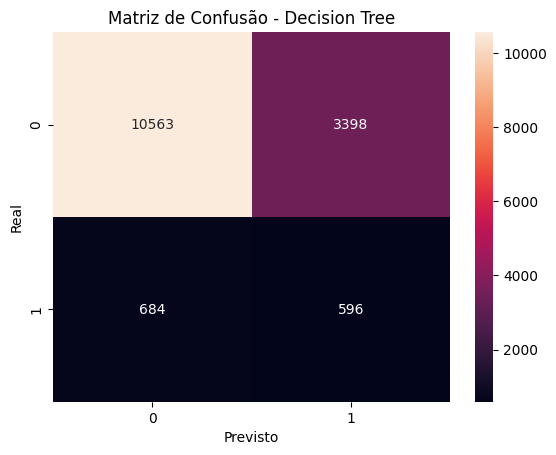

In [18]:
print("PIPELINE 2 - DECISION TREE")



modelo_dt = DecisionTreeClassifier(

    max_depth=6,

    min_samples_split=10,

    random_state=42

)



modelo_dt.fit(

    X_train_balanced,

    y_train_balanced

)



avaliar(

    "Decision Tree",

    modelo_dt,

    X_test,

    y_test

)

# PIPELINE 3 - RANDOM FOREST

PIPELINE 3 - RANDOM FOREST
Random Forest
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     13961
           1       0.17      0.46      0.25      1280

    accuracy                           0.76     15241
   macro avg       0.55      0.63      0.55     15241
weighted avg       0.88      0.76      0.81     15241



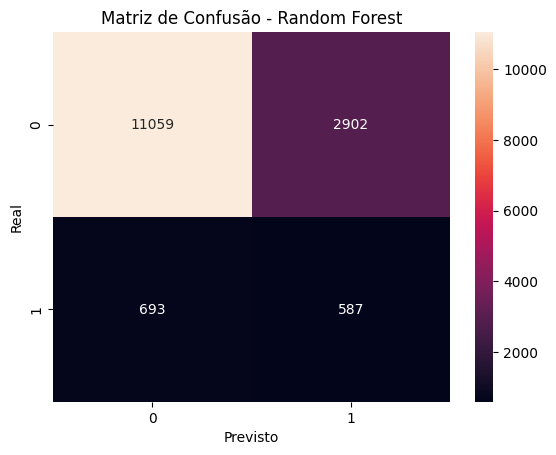

In [19]:
print("PIPELINE 3 - RANDOM FOREST")



modelo_rf = RandomForestClassifier(

    n_estimators=100,

    max_depth=10,

    random_state=42,

    class_weight=None

)



modelo_rf.fit(

    X_train_balanced,

    y_train_balanced

)



avaliar(

    "Random Forest",

    modelo_rf,

    X_test,

    y_test

)

# PIPELINE 4 - SUPPORT VECTOR MACHINE

In [20]:
print("PIPELINE 4 - SUPPORT VECTOR MACHINE")

modelo_svm = LinearSVC(
    C=1,
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)


modelo_svm.fit(
    X_train_scaled,
    y_train_balanced
)


y_pred_svm = modelo_svm.predict(
    X_test_scaled
)


print("="*60)
print("SVM")
print("="*60)


print(
    classification_report(
        y_test,
        y_pred_svm
    )
)


print("Matriz de Confusão")


print(
    confusion_matrix(
        y_test,
        y_pred_svm
    )
)


resultados.append({

    "Modelo": "SVM",

    "Accuracy":
    accuracy_score(
        y_test,
        y_pred_svm
    ),

    "Precision":
    precision_score(
        y_test,
        y_pred_svm
    ),

    "Recall":
    recall_score(
        y_test,
        y_pred_svm
    ),

    "F1":
    f1_score(
        y_test,
        y_pred_svm
    )

})

PIPELINE 4 - SUPPORT VECTOR MACHINE
SVM
              precision    recall  f1-score   support

           0       0.94      0.69      0.80     13961
           1       0.14      0.53      0.22      1280

    accuracy                           0.68     15241
   macro avg       0.54      0.61      0.51     15241
weighted avg       0.87      0.68      0.75     15241

Matriz de Confusão
[[9654 4307]
 [ 598  682]]


# PIPELINE 5 - KNN

PIPELINE 5 - KNN
KNN
              precision    recall  f1-score   support

           0       0.93      0.81      0.87     13961
           1       0.15      0.38      0.22      1280

    accuracy                           0.77     15241
   macro avg       0.54      0.59      0.54     15241
weighted avg       0.87      0.77      0.81     15241



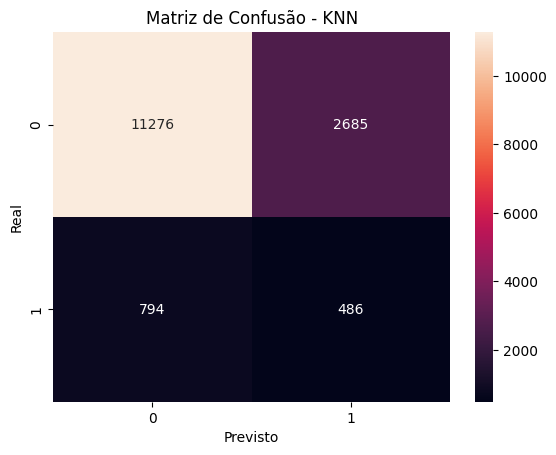

In [21]:
print("PIPELINE 5 - KNN")



modelo_knn = KNeighborsClassifier(

    n_neighbors=5

)



modelo_knn.fit(

    X_train_scaled,

    y_train_balanced

)



avaliar(

    "KNN",

    modelo_knn,

    X_test_scaled,

    y_test

)

# PIPELINE 6 - REDE NEURAL MLP

PIPELINE 6 - MLP
MLP - Rede Neural
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     13961
           1       0.17      0.30      0.22      1280

    accuracy                           0.82     15241
   macro avg       0.55      0.58      0.56     15241
weighted avg       0.87      0.82      0.84     15241



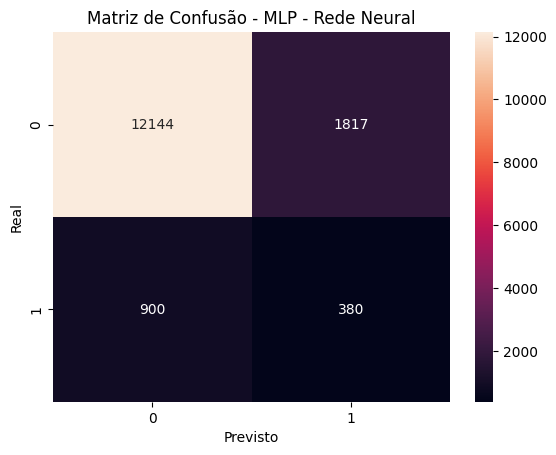

In [22]:
print("PIPELINE 6 - MLP")



modelo_mlp = MLPClassifier(

    hidden_layer_sizes=(50,30),

    max_iter=500,

    random_state=42

)



modelo_mlp.fit(

    X_train_scaled,

    y_train_balanced

)



avaliar(

    "MLP - Rede Neural",

    modelo_mlp,

    X_test_scaled,

    y_test

)

# COMPARAÇÃO DOS RESULTADOS

In [23]:

df_resultados = pd.DataFrame(resultados)



df_resultados = df_resultados.sort_values(

    by='Recall',

    ascending=False

)



df_resultados

,Modelo,Accuracy,Precision,Recall,F1
2,SVM,0.678171,0.136701,0.532813,0.217579
0,Decision Tree,0.732170,0.149224,0.465625,0.226014
1,Random Forest,0.764123,0.168243,0.458594,0.246173
3,KNN,0.771734,0.153264,0.379688,0.218378
4,MLP - Rede Neural,0.821731,0.172963,0.296875,0.218579


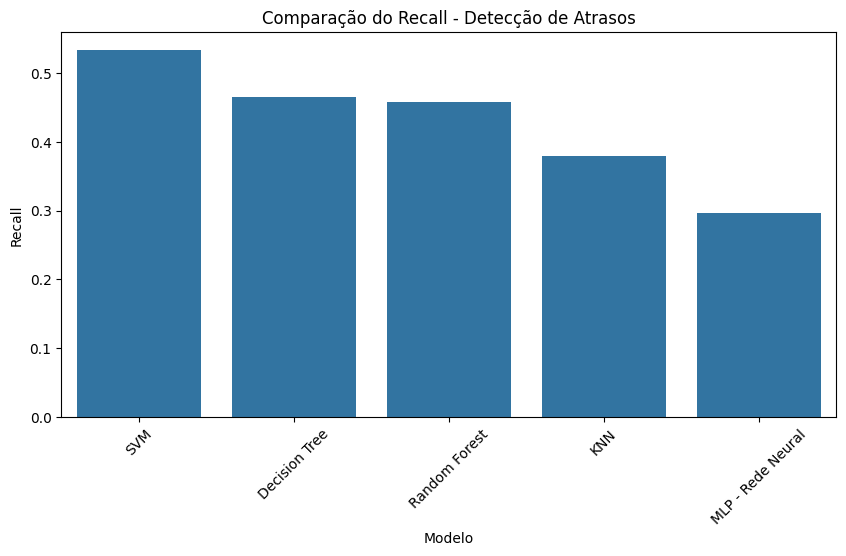

In [24]:
plt.figure(figsize=(10,5))


sns.barplot(

    data=df_resultados,

    x='Modelo',

    y='Recall'

)


plt.title(
    "Comparação do Recall - Detecção de Atrasos"
)


plt.xticks(rotation=45)


plt.show()